# EDA — GRUPO DE TESTE

Dataset: `ilkeryildiz/example-dataset-for-ab-test` · campanha `Test Campaign`.

Este notebook roda a partir da raiz do projeto. O CSV é separado por `;` e a
coluna de data vem em `dd.mm.aaaa`.

In [1]:
import pandas as pd

pd.set_option("display.width", 200)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('husl')

In [3]:
# O CSV usa ';' como separador. O caminho e relativo a raiz do repo, entao
# o notebook roda em qualquer maquina depois de abrir a pasta do projeto.
df = pd.read_csv("../data/test_group.csv", sep=";")
df["Date"] = pd.to_datetime(df["Date"], format="%d.%m.%Y", dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)
print("GRUPO DE TESTE - {} dias".format(len(df)))

GRUPO DE TESTE - 30 dias


In [4]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,2019-08-01,3008,39550.0,35820.0,3038.0,1946.0,1069.0,894.0,255.0
1,Test Campaign,2019-08-02,2542,100719.0,91236.0,4657.0,2359.0,1548.0,879.0,677.0
2,Test Campaign,2019-08-03,2365,70263.0,45198.0,7885.0,2572.0,2367.0,1268.0,578.0
3,Test Campaign,2019-08-04,2710,78451.0,25937.0,4216.0,2216.0,1437.0,566.0,340.0
4,Test Campaign,2019-08-05,2297,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Campaign Name        30 non-null     str           
 1   Date                 30 non-null     datetime64[us]
 2   Spend [USD]          30 non-null     int64         
 3   # of Impressions     29 non-null     float64       
 4   Reach                29 non-null     float64       
 5   # of Website Clicks  29 non-null     float64       
 6   # of Searches        29 non-null     float64       
 7   # of View Content    29 non-null     float64       
 8   # of Add to Cart     29 non-null     float64       
 9   # of Purchase        29 non-null     float64       
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 2.9 KB


In [6]:
df.describe()

,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
count,30,30.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,2019-08-15 12:00:00,2563.066667,73215.482759,52055.482759,6038.172414,2429.758621,1892.482759,878.965517,512.724138
min,2019-08-01 00:00:00,1968.000000,22521.000000,10598.000000,3038.000000,1854.000000,1046.000000,278.000000,238.000000
25%,2019-08-08 06:00:00,2324.500000,45511.000000,31489.000000,4399.000000,2037.000000,1437.000000,566.000000,284.000000
50%,2019-08-15 12:00:00,2584.000000,67444.000000,43241.000000,6435.000000,2432.000000,1894.000000,992.000000,488.000000
75%,2019-08-22 18:00:00,2836.250000,95843.000000,76219.000000,7617.000000,2824.000000,2427.000000,1168.000000,677.000000
max,2019-08-30 00:00:00,3112.000000,133771.000000,109834.000000,8264.000000,2978.000000,2801.000000,1391.000000,890.000000
std,NaN,348.687681,31786.355952,28190.975729,1738.505086,391.022986,577.063355,353.446953,209.480633


## Séries diárias

Spend e impressões ao longo dos 30 dias, para ver se há sazonalidade que
possa confundir a comparação entre os grupos.

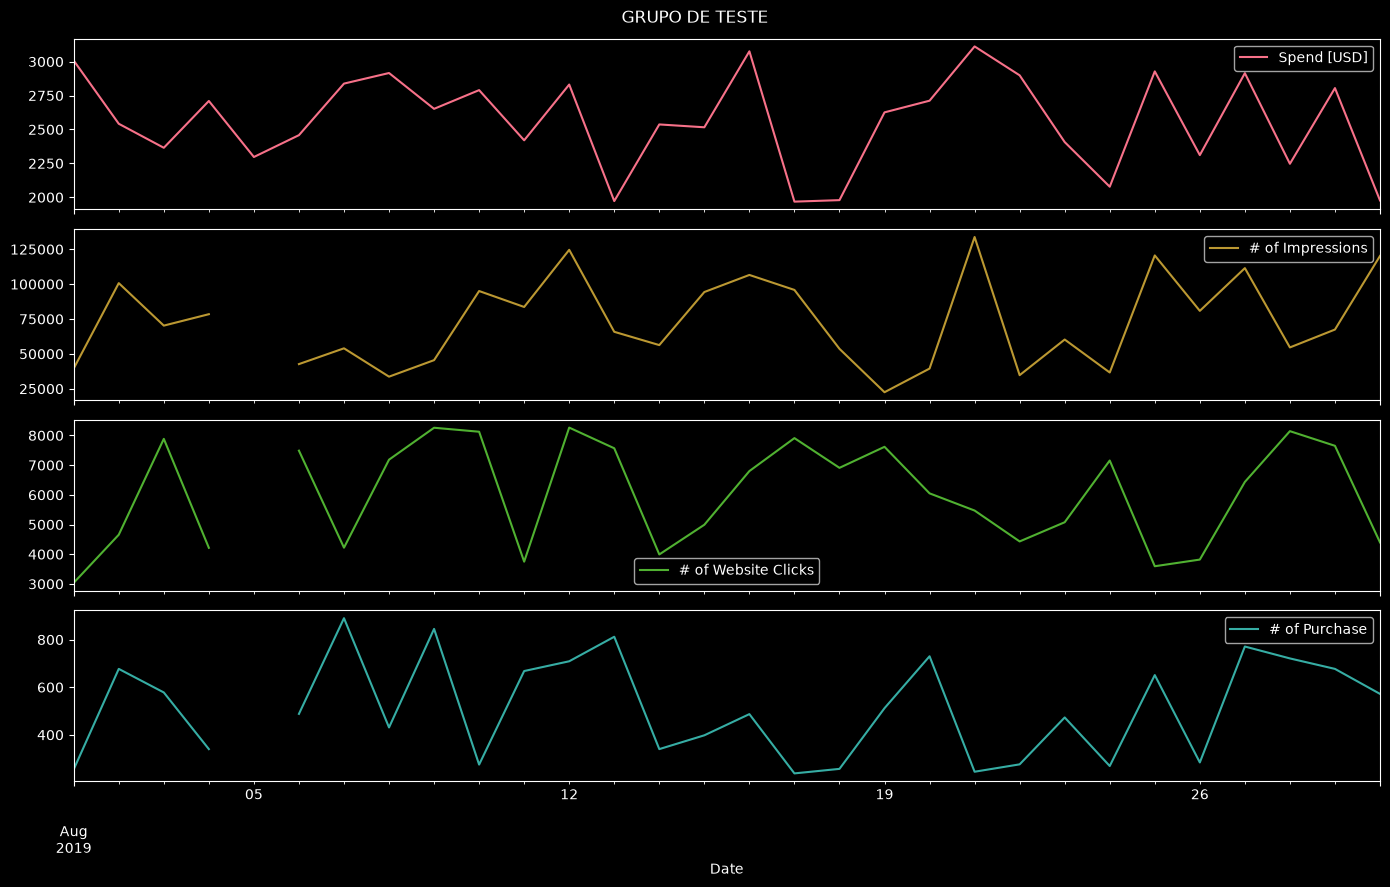

In [7]:
df.set_index("Date")[["Spend [USD]", "# of Impressions", "# of Website Clicks", "# of Purchase"]].plot(
    subplots=True, figsize=(14, 9), sharex=True, title="GRUPO DE TESTE"
)
plt.tight_layout()
plt.show()